In [2]:
%pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("../data/processed_data/risk_regression_data.csv")
df.head()


,project_id,company_name,sector,initial_investment,negative II,cashflow_y1,cashflow_y2,cashflow_y3,risk_score,discount_rate,NPV
0,P1,Apple,tech,4.993920e+10,-4.993920e+10,1.098662e+10,1.747872e+10,1.947629e+10,2,0.08,-9.320309e+09
1,P2,Apple,tech,2.496960e+10,-2.496960e+10,7.490880e+09,6.492096e+09,7.490880e+09,4,0.10,-7.166331e+09
2,P3,Apple,tech,4.161600e+10,-4.161600e+10,1.206864e+10,1.290096e+10,1.747872e+10,4,0.10,-6.850538e+09
3,P4,Apple,tech,4.577760e+10,-4.577760e+10,1.510661e+10,1.693771e+10,1.785326e+10,2,0.08,-3.096145e+09
4,P5,Apple,tech,5.410080e+10,-5.410080e+10,1.731226e+10,2.109931e+10,2.434536e+10,4,0.10,-2.633908e+09


In [5]:
X = df[
    [
        "initial_investment",
        "cashflow_y1",
        "cashflow_y2",
        "cashflow_y3",
        "discount_rate",
        "NPV"
    ]
]

y = df["risk_score"]


splitting the data into training data and testing data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))


MAE: 0.5896109509311531
R² score: 0.8277910216172453


explaining the model

In [9]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df


,Feature,Coefficient
4,discount_rate,1.316710e+02
0,initial_investment,6.356756e-11
5,NPV,6.050992e-11
3,cashflow_y3,-4.506788e-11
2,cashflow_y2,-5.521399e-11
1,cashflow_y1,-5.554235e-11


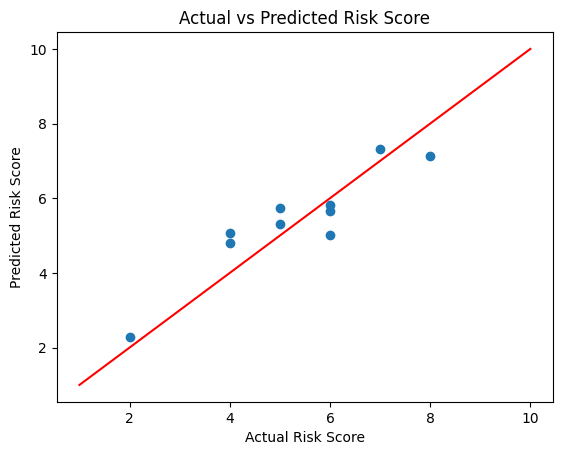

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk Score")
plt.plot([1,10], [1,10], color="red")  # ideal line
plt.show()
